In [1]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 5.4 MB/s eta 0:00:00:00:0100:01


In [2]:
!pip install faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 55.6 MB/s eta 0:00:0000:01:00:01


In [4]:



# ============================================================
# IMPORTS
# ============================================================

import os
import cv2
import random
import pickle
import numpy as np
import onnxruntime as ort
import faiss

from glob import glob
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score


# ============================================================
# CONFIG
# ============================================================

class Config:
    # Kaggle paths
    data_root = "/kaggle/input/datasets/nguynkuan/arcface1/data_arcface112_aligned_2.5g"
    model_path = "/kaggle/input/models/nguynkuan/mbf/onnx/mbf/1/w600k_mbf.onnx"

    save_dir = "/kaggle/working"

    gallery_save_path = "/kaggle/working/gallery_mobilefacenet1.pkl"
    faiss_index_path = "/kaggle/working/face_gallery1.index"
    faiss_names_path = "/kaggle/working/face_names1.pkl"

    min_images = 20
    max_gallery_per_identity = 15

    input_size = 112

    # threshold demo
    threshold = 0.22

    num_pairs = 3000
    seed = 42
    batch_size = 64

    blur_threshold = 80.0


cfg = Config()

random.seed(cfg.seed)
np.random.seed(cfg.seed)

os.makedirs(cfg.save_dir, exist_ok=True)


# ============================================================
# LOAD ONNX MODEL
# ============================================================

os.system("pip install onnxruntime-gpu -q")

available = ort.get_available_providers()
print("Available providers:", available)

if "CUDAExecutionProvider" in available:
    providers = [
        (
            "CUDAExecutionProvider",
            {
                "device_id": 0,
                "arena_extend_strategy": "kNextPowerOfTwo",
                "gpu_mem_limit": 14 * 1024 * 1024 * 1024,
                "cudnn_conv_algo_search": "EXHAUSTIVE",
            },
        ),
        "CPUExecutionProvider",
    ]
    print("✅ Running GPU")
else:
    providers = ["CPUExecutionProvider"]
    print("⚠️ Running CPU")

so = ort.SessionOptions()
so.log_severity_level = 3

session = ort.InferenceSession(
    cfg.model_path,
    sess_options=so,
    providers=providers
)

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

print("ONNX providers :", session.get_providers())
print("Input shape    :", session.get_inputs()[0].shape)


# ============================================================
# UTILS
# ============================================================

def l2_norm(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)


def is_good_image(img_path, blur_threshold=80.0):
    img = cv2.imread(img_path)

    if img is None:
        return False

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    if blur_score < blur_threshold:
        return False

    return True


# ============================================================
# BATCH EMBEDDING
# ============================================================

def extract_embeddings_batch(img_paths, batch_size=64, desc="Batch inference"):
    result = {}

    for i in tqdm(
        range(0, len(img_paths), batch_size),
        desc=desc
    ):
        batch_paths = img_paths[i:i + batch_size]

        batch_imgs = []
        batch_valid = []

        for path in batch_paths:
            img = cv2.imread(path)

            if img is None:
                continue

            img = cv2.resize(
                img,
                (cfg.input_size, cfg.input_size),
                interpolation=cv2.INTER_LINEAR
            )

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = img.astype(np.float32)
            img = (img - 127.5) / 127.5
            img = np.transpose(img, (2, 0, 1))

            batch_imgs.append(img)
            batch_valid.append(path)

        if len(batch_imgs) == 0:
            continue

        batch_arr = np.asarray(batch_imgs, dtype=np.float32)

        embs = session.run(
            [output_name],
            {input_name: batch_arr}
        )[0]

        embs = l2_norm(embs)

        for path, emb in zip(batch_valid, embs):
            result[path] = emb.astype(np.float32)

    return result


# ============================================================
# LOAD DATASET
# ============================================================

def load_dataset(data_root, min_images=20):
    identities = sorted([
        f for f in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, f))
    ])

    dataset = {}
    skipped = 0

    for name in tqdm(identities, desc="[1/6] Loading dataset"):
        folder = os.path.join(data_root, name)

        raw_images = (
            glob(os.path.join(folder, "*.jpg")) +
            glob(os.path.join(folder, "*.jpeg")) +
            glob(os.path.join(folder, "*.png"))
        )

        images = [
            p for p in raw_images
            if is_good_image(p, cfg.blur_threshold)
        ]

        if len(images) >= min_images:
            dataset[name] = images
        else:
            skipped += 1

    print("\nTotal identities :", len(identities))
    print("Valid identities :", len(dataset))
    print("Skipped          :", skipped)

    return dataset


dataset = load_dataset(
    cfg.data_root,
    cfg.min_images
)


# ============================================================
# SPLIT GALLERY / PROBE
# ============================================================

def split_gallery_probe(dataset):
    gallery = {}
    probe = {}

    for name, images in dataset.items():
        images = images.copy()
        random.shuffle(images)

        n_gallery = min(
            cfg.max_gallery_per_identity,
            len(images) - 1
        )

        gallery[name] = images[:n_gallery]
        probe[name] = images[n_gallery:]

        if len(probe[name]) == 0:
            probe[name] = images[-1:]
            gallery[name] = images[:-1]

    return gallery, probe


gallery_paths, probe_paths = split_gallery_probe(dataset)

print("\nGallery identities :", len(gallery_paths))
print("Probe identities   :", len(probe_paths))


# ============================================================
# BUILD GALLERY DB
# ============================================================

def build_gallery(gallery_paths, batch_size=64):
    all_paths = []

    for images in gallery_paths.values():
        all_paths.extend(images)

    print("\nTotal gallery images :", len(all_paths))

    emb_map = extract_embeddings_batch(
        all_paths,
        batch_size,
        desc="[2/6] Extract gallery embeddings"
    )

    gallery_db = {}

    for name, images in tqdm(
        gallery_paths.items(),
        desc="[3/6] Build gallery DB"
    ):
        embs = [
            emb_map[p]
            for p in images
            if p in emb_map
        ]

        if len(embs) == 0:
            continue

        mean_emb = np.mean(
            np.vstack(embs),
            axis=0,
            keepdims=True
        )

        gallery_db[name] = l2_norm(mean_emb)[0].astype(np.float32)

    return gallery_db


gallery_db = build_gallery(
    gallery_paths,
    cfg.batch_size
)

print("\nGallery DB :", len(gallery_db), "identities")


# ============================================================
# SAVE GALLERY DB
# ============================================================

with open(cfg.gallery_save_path, "wb") as f:
    pickle.dump(gallery_db, f)

print("\nGallery saved:")
print(cfg.gallery_save_path)


# ============================================================
# BUILD + SAVE FAISS INDEX
# ============================================================

gallery_names = list(gallery_db.keys())

gallery_embs = np.vstack([
    gallery_db[name]
    for name in gallery_names
]).astype("float32")

# cosine similarity = inner product if vectors are L2-normalized
faiss.normalize_L2(gallery_embs)

index = faiss.IndexFlatIP(gallery_embs.shape[1])
index.add(gallery_embs)

faiss.write_index(index, cfg.faiss_index_path)

with open(cfg.faiss_names_path, "wb") as f:
    pickle.dump(gallery_names, f)

print("\nFAISS index built")
print("Total vectors:", index.ntotal)
print("FAISS index saved:", cfg.faiss_index_path)
print("FAISS names saved:", cfg.faiss_names_path)


# ============================================================
# IDENTIFICATION WITH FAISS
# ============================================================

all_probe_paths = []
probe_labels = []

for true_name, images in probe_paths.items():
    for img_path in images:
        all_probe_paths.append(img_path)
        probe_labels.append(true_name)

print("\nTotal probe images :", len(all_probe_paths))

probe_emb_map = extract_embeddings_batch(
    all_probe_paths,
    cfg.batch_size,
    desc="[4/6] Extract probe embeddings"
)

y_true = []
y_pred = []
scores = []

for img_path, true_name in tqdm(
    zip(all_probe_paths, probe_labels),
    total=len(all_probe_paths),
    desc="[5/6] Identification with FAISS"
):
    if img_path not in probe_emb_map:
        continue

    emb = probe_emb_map[img_path].astype("float32").reshape(1, -1)
    faiss.normalize_L2(emb)

    score_arr, idx_arr = index.search(emb, 1)

    best_score = float(score_arr[0][0])
    best_idx = int(idx_arr[0][0])
    best_name = gallery_names[best_idx]

    if best_score < cfg.threshold:
        best_name = "unknown"

    y_true.append(true_name)
    y_pred.append(best_name)
    scores.append(best_score)


acc = accuracy_score(y_true, y_pred)

print("\n" + "=" * 50)
print("IDENTIFICATION RESULT - FAISS")
print("=" * 50)
print(f"Accuracy     : {acc * 100:.2f}%")
print(f"Threshold    : {cfg.threshold}")
print(f"Total probes : {len(y_true)}")
print("=" * 50)

wrong = [
    (t, p, s)
    for t, p, s in zip(y_true, y_pred, scores)
    if t != p
]

print("\nWrong predictions :", len(wrong))

for t, p, s in wrong[:20]:
    print(f"True: {t} | Pred: {p} | Score: {s:.4f}")


# ============================================================
# VERIFICATION
# ============================================================

def create_pairs(dataset, num_pairs=3000, seed=42):
    rng = np.random.RandomState(seed)

    names = list(dataset.keys())
    valid = [n for n in names if len(dataset[n]) >= 2]

    half = num_pairs // 2

    pos_pairs = []
    neg_pairs = []

    while len(pos_pairs) < half:
        name = rng.choice(valid)

        img1, img2 = rng.choice(
            dataset[name],
            2,
            replace=False
        )

        pos_pairs.append((img1, img2, 1))

    while len(neg_pairs) < half:
        n1, n2 = rng.choice(
            valid,
            2,
            replace=False
        )

        img1 = rng.choice(dataset[n1])
        img2 = rng.choice(dataset[n2])

        neg_pairs.append((img1, img2, 0))

    pairs = pos_pairs + neg_pairs
    rng.shuffle(pairs)

    return pairs


def compute_verification(dataset, num_pairs=3000):
    pairs = create_pairs(
        dataset,
        num_pairs,
        cfg.seed
    )

    unique_paths = list(set(
        [p for p, _, _ in pairs] +
        [p for _, p, _ in pairs]
    ))

    print("\nUnique verification images :", len(unique_paths))

    emb_cache = extract_embeddings_batch(
        unique_paths,
        cfg.batch_size,
        desc="[6/6] Extract verification embeddings"
    )

    sims = []
    labels = []

    for img1, img2, label in pairs:
        e1 = emb_cache.get(img1)
        e2 = emb_cache.get(img2)

        if e1 is None or e2 is None:
            continue

        sims.append(float(np.dot(e1, e2)))
        labels.append(label)

    sims = np.array(sims)
    labels = np.array(labels)

    thresholds = np.linspace(0.1, 0.8, 5000)

    best_acc = 0
    best_th = 0

    fars = []
    frrs = []

    pos_mask = labels == 1
    neg_mask = labels == 0

    for th in tqdm(thresholds, desc="Compute metrics"):
        preds = (sims >= th).astype(int)

        acc = np.mean(preds == labels)

        far = (
            np.sum((preds == 1) & neg_mask)
            / np.sum(neg_mask)
        )

        frr = (
            np.sum((preds == 0) & pos_mask)
            / np.sum(pos_mask)
        )

        fars.append(far)
        frrs.append(frr)

        if acc > best_acc:
            best_acc = acc
            best_th = th

    fars = np.array(fars)
    frrs = np.array(frrs)

    eer_idx = np.argmin(
        np.abs(fars - frrs)
    )

    eer = (
        fars[eer_idx] +
        frrs[eer_idx]
    ) / 2

    auc = roc_auc_score(labels, sims)
    
    print("\n" + "=" * 50)
    print("VERIFICATION RESULT")
    print("=" * 50)
    print(f"Verification Accuracy : {best_acc * 100:.2f}%")
    print(f"Best Threshold        : {best_th:.4f}")
    print(f"EER                   : {eer * 100:.4f}%")
    print(f"AUC                   : {auc:.6f}")
    print(f"FAR                   : {fars[eer_idx] * 100:.4f}%")
    print(f"FRR                   : {frrs[eer_idx] * 100:.4f}%")
    print(f"Mean Cos Same         : {np.mean(sims[pos_mask]):.4f}")
    print(f"Mean Cos Diff         : {np.mean(sims[neg_mask]):.4f}")
    print("=" * 50)
    print(f"\n→ Recommended camera threshold : {best_th:.4f}")
    print(f"→ Current recognition threshold: {cfg.threshold}")

    return {
        "accuracy": best_acc,
        "threshold": best_th,
        "eer": eer,
        "auc": auc,
        "mean_same": np.mean(sims[pos_mask]),
        "mean_diff": np.mean(sims[neg_mask]),
        "labels": labels,
        "sims": sims,
        "fars": fars,
        "frrs": frrs,
        "thresholds": thresholds,
    }


verification_results = compute_verification(
    dataset,
    cfg.num_pairs
)
labels = verification_results["labels"]
sims = verification_results["sims"]
fars = verification_results["fars"]
frrs = verification_results["frrs"]
thresholds = verification_results["thresholds"]
print("\nDONE")

Available providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
✅ Running GPU
ONNX providers : ['CUDAExecutionProvider', 'CPUExecutionProvider']
Input shape    : ['None', 3, 112, 112]


[1/6] Loading dataset:   0%|          | 0/270 [00:00<?, ?it/s]


Total identities : 270
Valid identities : 186
Skipped          : 84

Gallery identities : 186
Probe identities   : 186

Total gallery images : 2790


[2/6] Extract gallery embeddings:   0%|          | 0/44 [00:00<?, ?it/s]

[3/6] Build gallery DB:   0%|          | 0/186 [00:00<?, ?it/s]

...

[5/6] Identification with FAISS:   0%|          | 0/23245 [00:00<?, ?it/s]


IDENTIFICATION RESULT - FAISS
Accuracy     : 93.07%
Threshold    : 0.22
Total probes : 23245

Wrong predictions : 1611
True: . Sato Shori | Pred: Okura Tadayoshi | Score: 0.3961
True: . Sato Shori | Pred: Seto Koji | Score: 0.4335
True: . Sato Shori | Pred: Okura Tadayoshi | Score: 0.3805
True: . Sato Shori | Pred: Wannnaone_Jinyoung | Score: 0.4661
True: . Sato Shori | Pred: Iijima Hiroki | Score: 0.3487
True: . Sato Shori | Pred: Nissy | Score: 0.3823
True: . Sato Shori | Pred: Apink_kyung | Score: 0.3252
True: . Sato Shori | Pred: marius yo | Score: 0.6141
True: . Sato Shori | Pred: Iijima Hiroki | Score: 0.4265
True: . Sato Shori | Pred: Matsushima So | Score: 0.6726
True: . Sato Shori | Pred: Chinen Yuuri | Score: 0.4123
True: . Sato Shori | Pred: Matsushima So | Score: 0.5366
True: . Sato Shori | Pred: Fukushi Souta | Score: 0.3167
True: . Sato Shori | Pred: Okura Tadayoshi | Score: 0.3607
True: . Sato Shori | Pred: Iwata Takanori | Score: 0.4099
True: . Sato Shori | Pred: Nakan

[6/6] Extract verification embeddings:   0%|          | 0/80 [00:00<?, ?it/s]

Compute metrics:   0%|          | 0/5000 [00:00<?, ?it/s]


VERIFICATION RESULT
Verification Accuracy : 93.00%
Best Threshold        : 0.2033
EER                   : 8.8667%
AUC                   : 0.964666
FAR                   : 8.8667%
FRR                   : 8.8667%
Mean Cos Same         : 0.4122
Mean Cos Diff         : 0.0320

→ Recommended camera threshold : 0.2033
→ Current recognition threshold: 0.22

DONE


In [10]:
def create_pairs(dataset, num_pairs=3000, seed=42):
    rng = np.random.RandomState(seed)

    names = list(dataset.keys())
    valid = [n for n in names if len(dataset[n]) >= 2]

    half = num_pairs // 2

    pos_pairs = []
    neg_pairs = []

    while len(pos_pairs) < half:
        name = rng.choice(valid)

        img1, img2 = rng.choice(
            dataset[name],
            2,
            replace=False
        )

        pos_pairs.append((img1, img2, 1))

    while len(neg_pairs) < half:
        n1, n2 = rng.choice(
            valid,
            2,
            replace=False
        )

        img1 = rng.choice(dataset[n1])
        img2 = rng.choice(dataset[n2])

        neg_pairs.append((img1, img2, 0))

    pairs = pos_pairs + neg_pairs
    rng.shuffle(pairs)

    return pairs


def compute_verification(dataset, num_pairs=3000):
    pairs = create_pairs(
        dataset,
        num_pairs,
        cfg.seed
    )

    unique_paths = list(set(
        [p for p, _, _ in pairs] +
        [p for _, p, _ in pairs]
    ))

    print("\nUnique verification images :", len(unique_paths))

    emb_cache = extract_embeddings_batch(
        unique_paths,
        cfg.batch_size,
        desc="[6/6] Extract verification embeddings"
    )

    sims = []
    labels = []

    for img1, img2, label in pairs:
        e1 = emb_cache.get(img1)
        e2 = emb_cache.get(img2)

        if e1 is None or e2 is None:
            continue

        sims.append(float(np.dot(e1, e2)))
        labels.append(label)

    sims = np.array(sims)
    labels = np.array(labels)

    thresholds = np.linspace(0.1, 0.8, 5000)

    best_acc = 0
    best_th = 0

    fars = []
    frrs = []

    pos_mask = labels == 1
    neg_mask = labels == 0

    for th in tqdm(thresholds, desc="Compute metrics"):
        preds = (sims >= th).astype(int)

        acc = np.mean(preds == labels)

        far = (
            np.sum((preds == 1) & neg_mask)
            / np.sum(neg_mask)
        )

        frr = (
            np.sum((preds == 0) & pos_mask)
            / np.sum(pos_mask)
        )

        fars.append(far)
        frrs.append(frr)

        if acc > best_acc:
            best_acc = acc
            best_th = th

    fars = np.array(fars)
    frrs = np.array(frrs)

    eer_idx = np.argmin(
        np.abs(fars - frrs)
    )

    eer = (
        fars[eer_idx] +
        frrs[eer_idx]
    ) / 2

    auc = roc_auc_score(labels, sims)
    
    print("\n" + "=" * 50)
    print("VERIFICATION RESULT")
    print("=" * 50)
    print(f"Verification Accuracy : {best_acc * 100:.2f}%")
    print(f"Best Threshold        : {best_th:.4f}")
    print(f"EER                   : {eer * 100:.4f}%")
    print(f"AUC                   : {auc:.6f}")
    print(f"FAR                   : {fars[eer_idx] * 100:.4f}%")
    print(f"FRR                   : {frrs[eer_idx] * 100:.4f}%")
    print(f"Mean Cos Same         : {np.mean(sims[pos_mask]):.4f}")
    print(f"Mean Cos Diff         : {np.mean(sims[neg_mask]):.4f}")
    print("=" * 50)
    print(f"\n→ Recommended camera threshold : {best_th:.4f}")
    print(f"→ Current recognition threshold: {cfg.threshold}")

    return {
        "accuracy": best_acc,
        "threshold": best_th,
        "eer": eer,
        "auc": auc,
        "mean_same": np.mean(sims[pos_mask]),
        "mean_diff": np.mean(sims[neg_mask]),
        "labels": labels,
        "sims": sims,
        "fars": fars,
        "frrs": frrs,
        "thresholds": thresholds,
    }


verification_results = compute_verification(
    dataset,
    cfg.num_pairs
)
labels = verification_results["labels"]
sims = verification_results["sims"]
fars = verification_results["fars"]
frrs = verification_results["frrs"]
thresholds = verification_results["thresholds"]
best_th = verification_results["threshold"]
pos_mask = labels == 1
neg_mask = labels == 0
print("\nDONE")


Unique verification images : 5112


[6/6] Extract verification embeddings:   0%|          | 0/80 [00:00<?, ?it/s]

Compute metrics:   0%|          | 0/5000 [00:00<?, ?it/s]


VERIFICATION RESULT
Verification Accuracy : 93.00%
Best Threshold        : 0.2033
EER                   : 8.8667%
AUC                   : 0.964666
FAR                   : 8.8667%
FRR                   : 8.8667%
Mean Cos Same         : 0.4122
Mean Cos Diff         : 0.0320

→ Recommended camera threshold : 0.2033
→ Current recognition threshold: 0.22

DONE


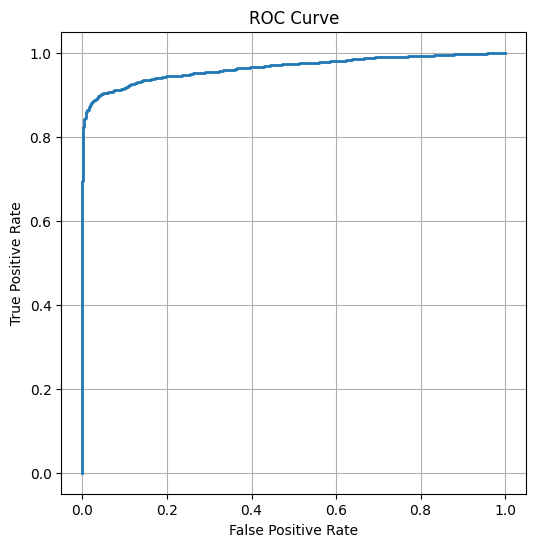

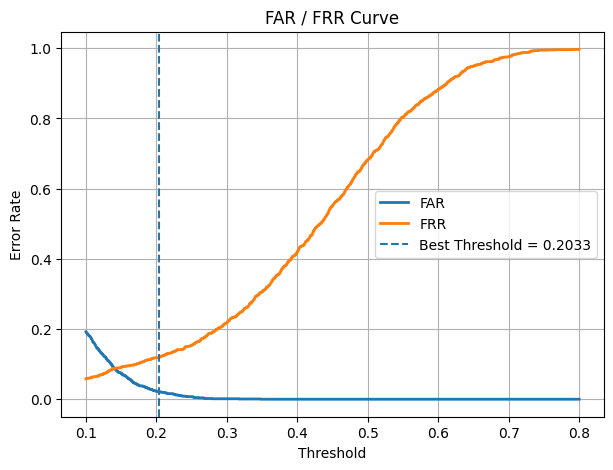

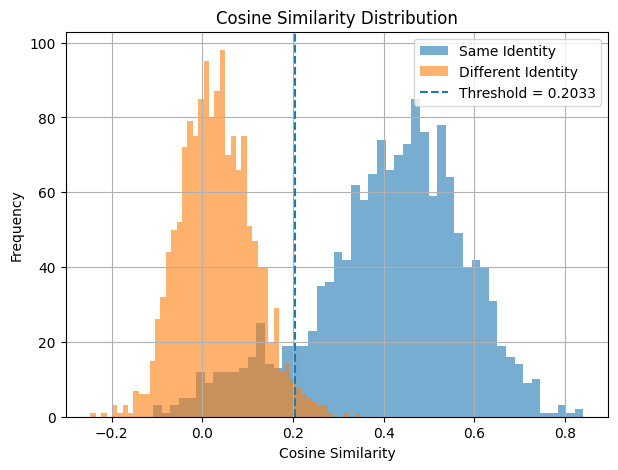

In [11]:
import matplotlib.pyplot as plt

# ============================================================
# ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(labels, sims)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.show()


# ============================================================
# FAR - FRR CURVE
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(
    thresholds,
    fars,
    label="FAR",
    linewidth=2
)

plt.plot(
    thresholds,
    frrs,
    label="FRR",
    linewidth=2
)

plt.axvline(
    best_th,
    linestyle="--",
    label=f"Best Threshold = {best_th:.4f}"
)

plt.xlabel("Threshold")
plt.ylabel("Error Rate")
plt.title("FAR / FRR Curve")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# COSINE DISTRIBUTION
# ============================================================

plt.figure(figsize=(7,5))

plt.hist(
    sims[pos_mask],
    bins=50,
    alpha=0.6,
    label="Same Identity"
)

plt.hist(
    sims[neg_mask],
    bins=50,
    alpha=0.6,
    label="Different Identity"
)

plt.axvline(
    best_th,
    linestyle="--",
    label=f"Threshold = {best_th:.4f}"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Cosine Similarity Distribution")
plt.legend()
plt.grid(True)
plt.show()

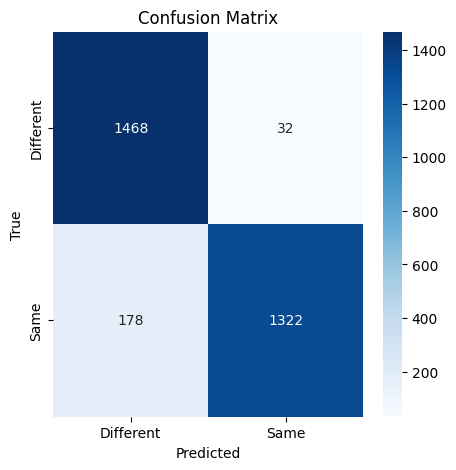

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# verification prediction
preds = (sims >= best_th).astype(int)

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Different", "Same"],
    yticklabels=["Different", "Same"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [5]:
# ============================================================
# TEST IMAGE / TEST FOLDER WITH FAISS
# ============================================================

import os
import cv2
import pickle
import numpy as np
import onnxruntime as ort
import faiss

from glob import glob
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


# ============================================================
# CONFIG TEST
# ============================================================

class TestConfig:
    model_path = "/kaggle/input/models/nguynkuan/mbf/onnx/mbf/1/w600k_mbf.onnx"

    faiss_index_path = "/kaggle/input/models/nguynkuan/arcefacee/other/default/1/face_gallery.index"
    faiss_names_path = "/kaggle/input/models/nguynkuan/arcefacee/other/default/1/face_names.pkl"

    input_size = 112

    threshold = 0.22

    top_k = 5


tcfg = TestConfig()


# ============================================================
# LOAD ONNX MODEL
# ============================================================

available = ort.get_available_providers()
print("Available providers:", available)

if "CUDAExecutionProvider" in available:
    providers = [
        ("CUDAExecutionProvider", {"device_id": 0}),
        "CPUExecutionProvider"
    ]
else:
    providers = ["CPUExecutionProvider"]

so = ort.SessionOptions()
so.log_severity_level = 3

session = ort.InferenceSession(
    tcfg.model_path,
    sess_options=so,
    providers=providers
)

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

print("ONNX providers:", session.get_providers())


# ============================================================
# LOAD FAISS INDEX + NAMES
# ============================================================

index = faiss.read_index(tcfg.faiss_index_path)

with open(tcfg.faiss_names_path, "rb") as f:
    gallery_names = pickle.load(f)

print("FAISS vectors:", index.ntotal)
print("Names:", len(gallery_names))


# ============================================================
# UTILS
# ============================================================

def l2_norm(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)


def preprocess_face(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None, None

    show_img = cv2.cvtColor(img.copy(), cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (tcfg.input_size, tcfg.input_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = img.astype(np.float32)
    img = (img - 127.5) / 127.5
    img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, axis=0).astype(np.float32)

    return img, show_img


def extract_embedding(img_path):
    inp, show_img = preprocess_face(img_path)

    if inp is None:
        return None, None

    emb = session.run(
        [output_name],
        {input_name: inp}
    )[0]

    emb = l2_norm(emb).astype("float32")

    return emb, show_img


def recognize_image(img_path, threshold=0.22, top_k=5):
    emb, show_img = extract_embedding(img_path)

    if emb is None:
        return {
            "path": img_path,
            "pred": "invalid image",
            "score": -1,
            "topk": [],
            "image": None
        }

    faiss.normalize_L2(emb)

    scores, idxs = index.search(emb, top_k)

    topk = []

    for score, idx in zip(scores[0], idxs[0]):
        if idx < 0:
            continue

        topk.append({
            "name": gallery_names[int(idx)],
            "score": float(score)
        })

    best_name = topk[0]["name"]
    best_score = topk[0]["score"]

    if best_score < threshold:
        pred = "unknown"
    else:
        pred = best_name

    return {
        "path": img_path,
        "pred": pred,
        "score": best_score,
        "topk": topk,
        "image": show_img
    }


# ============================================================
# TEST 1 IMAGE
# ============================================================

def test_one_image(img_path):
    result = recognize_image(
        img_path,
        threshold=tcfg.threshold,
        top_k=tcfg.top_k
    )

    print("\n" + "=" * 50)
    print("TEST IMAGE RESULT")
    print("=" * 50)
    print("Image :", img_path)
    print("Pred  :", result["pred"])
    print("Score :", f"{result['score']:.4f}")
    print("\nTop-k:")

    for i, item in enumerate(result["topk"], 1):
        print(f"{i}. {item['name']} | score={item['score']:.4f}")

    if result["image"] is not None:
        plt.figure(figsize=(4, 4))
        plt.imshow(result["image"])
        plt.axis("off")
        plt.title(f"{result['pred']} | {result['score']:.3f}")
        plt.show()

    return result


# ============================================================
# TEST FOLDER
# ============================================================

def test_folder(folder_path):
    images = (
        glob(os.path.join(folder_path, "*.jpg")) +
        glob(os.path.join(folder_path, "*.jpeg")) +
        glob(os.path.join(folder_path, "*.png"))
    )

    print("Total test images:", len(images))

    results = []

    for img_path in tqdm(images, desc="Testing folder"):
        result = recognize_image(
            img_path,
            threshold=tcfg.threshold,
            top_k=tcfg.top_k
        )

        results.append(result)

    for r in results[:20]:
        print(
            f"{os.path.basename(r['path'])} "
            f"=> {r['pred']} | score={r['score']:.4f}"
        )

    return results

Available providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
ONNX providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
FAISS vectors: 186
Names: 186


In [13]:
img_path = "/kaggle/input/datasets/nguynkuan/aaaaaaaaaaaa/z7828806604578_111e3123a117e154de1adf0037d5fcc0.jpg"
test_one_image(img_path)

NameError: name 'test_one_image' is not defined